In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
import symengine as se
import time
import sympy as sp

In [3]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [4]:
#heyoka integration

def hk_integrate(pham,sim_time,num_data_points):
    #H_num = pham.H.subs(dict(pham.H_params))
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                   if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols 
               if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2', 
                                  'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                  'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    
    rho1,rho2,sigma1,sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    #H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1,lam2 = se.symbols('lambda1 lambda2')
    Lam1,Lam2 = se.symbols('Lambda1 Lambda2')
    eta1,eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating  ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)

    deta1_dt  = se.diff(H_planar, kap1)
    dkap1_dt  =  -se.diff(H_planar, eta1)
    deta2_dt  = se.diff(H_planar, kap2)
    dkap2_dt  =  -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
    func = se.Lambdify(vars_list,H_planar)

    ast = pham.state.particles[1]
    jup = pham.state.particles[2]
    
    initial_conditions = [ast.l, ast.Lambda, jup.l, jup.Lambda,ast.eta, ast.kappa, jup.eta, jup.kappa]
    derivs_at_0 = func(*initial_conditions)

    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    eqs_hy = [hy.from_sympy(sp.sympify(eq), {sp.Symbol('lambda1'): lam1_hy, 
                                          sp.Symbol('Lambda1'): Lam1_hy,
                                          sp.Symbol('lambda2'): lam2_hy, 
                                          sp.Symbol('Lambda2'): Lam2_hy,
                                          sp.Symbol('eta1'): eta1_hy, 
                                          sp.Symbol('kappa1'): kap1_hy,
                                          sp.Symbol('eta2'): eta2_hy, 
                                          sp.Symbol('kappa2'): kap2_hy})
           for eq in derivs]

    ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-16)

    e_i = float(func(*ta.state))
    print(e_i)

    times = np.linspace(0,sim_time,int(num_data_points))*2*np.pi
    e_sat = np.zeros(len(times))
    pomega_sat = np.zeros(len(times))
    e_ast = np.zeros(len(times))

    start = time.perf_counter()
    print('*** Starting Simulation ***')
    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i],max_delta_t=10.0)
        L, eta, kap = ta.state[1], ta.state[4], ta.state[5]
        e_ast[i] = get_ecc(kap, eta, L)
        
    '''print('*** Starting Simulation ***')
    res, min_dt, max_dt, num_steps, callback, flat_states = ta.propagate_grid(times.tolist(), max_delta_t=0.1)

    flat_states = np.array(flat_states)

    num_vars = 8 
    state_matrix = flat_states.reshape(-1, num_vars)

    L_all   = state_matrix[:, 3]
    eta_all = state_matrix[:, 6]
    kap_all = state_matrix[:, 7]

    e_sat = get_ecc(kap_all, eta_all, L_all)
    pomega_sat = get_pomega(kap_all, eta_all)'''
    '''for i in tqdm(range(len(times))):
        ta.propagate_until(times[i],max_step=0.1)
        L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
        e_sat[i] = get_ecc(kap, eta, L)
        pomega_sat[i] = get_pomega(kap, eta)'''
        
    end = time.perf_counter()

    e_f = float(func(*ta.state))
    print(e_f)
    e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
    print(f'Energy Percent Change: {e_per} %')
    
    print('*** Simulation Complete ***')

    print('Time elapsed  = ' + str(end-start) + ' seconds')

    return times, e_ast

Initial Energy: -9.5632577687883e-05


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:17<00:00, 58.31it/s]


Final Energy: -9.56325776878833e-05
Energy Percent Change: 3.117719972022579e-13 %
Megno Value: 15.90921917390127


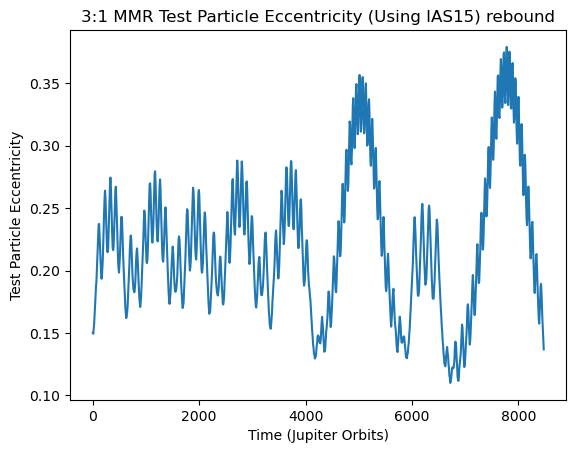

In [6]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")

sim.move_to_com()

times = np.linspace(0,16e3*2*np.pi,int(1e3))*2*np.pi
e_ast = np.zeros(len(times))
e_i = sim.energy()
print('Initial Energy: ' + str(e_i))

sim.init_megno()

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    e_ast[i] = sim.particles[1].e

e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Megno Value: ' + str(sim.megno()))

plt.plot(times/(2*np.pi)/11.86,e_ast)
plt.ylabel('Test Particle Eccentricity')
plt.xlabel("Time (Jupiter Orbits)")
plt.title('3:1 MMR Test Particle Eccentricity (Using IAS15) rebound')
plt.show()

Initial Energy: -9.5632577687883e-05


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:08<00:00, 12091.59it/s]


Final Energy: -9.56325776877492e-05
Energy Percent Change: 1.3991476947172238e-10 %
Megno Value: 206.16479646452098


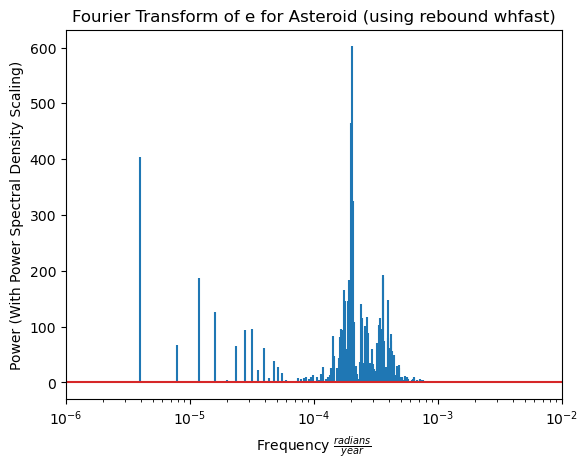

In [39]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")
sim.integrator = 'whfast'

sim.dt = sim.particles[1].P/20

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))
e_ast = np.zeros(len(times))
ast_pomega = np.zeros(len(times))

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))

sim.init_megno()

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    e_ast[i] = sim.particles[1].e
    ast_pomega[i] = sim.particles[1].pomega
    

e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Megno Value: ' + str(sim.megno()))

f,pxx = ft(times, e_ast)

plt.xlim(1e-6,1e-2)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.title('Fourier Transform of e for Asteroid (using rebound whfast)')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.show()

In [16]:
#testing with the wisdom 3:1 resonance textbook example page 461
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2,indexIn=1, indexOut=2, max_order=2) #3:1 MMR

times, e_ast = hk_integrate(pham,16e3*2*np.pi,1e3)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-9.563257764425922e-05
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:21<00:00, 45.62it/s]

-9.563257764453547e-05
Energy Percent Change: 2.888709269940817e-10 %
*** Simulation Complete ***
Time elapsed  = 19.7408468860001 seconds


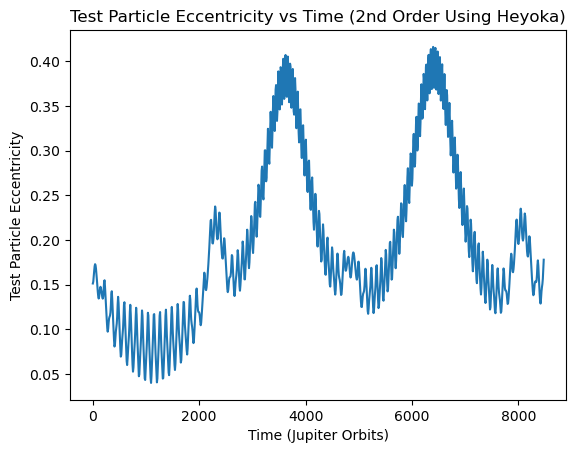

In [17]:
plt.plot(times/(2*np.pi)/11.86,e_ast)
plt.ylabel('Test Particle Eccentricity')
plt.title('Test Particle Eccentricity vs Time (2nd Order Using Heyoka)')
plt.xlabel("Time (Jupiter Orbits)")
plt.show()

Initial Energy: " -9.563257764425916e-05


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 194.28it/s]

Final Energy: " -9.563257764426025e-05
Energy Percent Change: 1.1337163539799131e-12 %


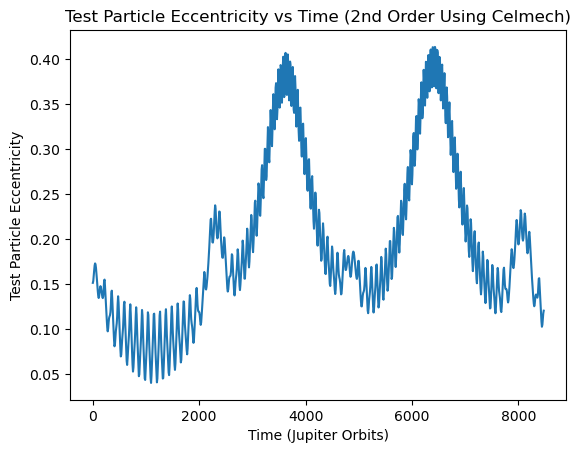

In [21]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")

sim.move_to_com()

times = np.linspace(0,16e3*np.pi*2,int(1e3))*2*np.pi
e_ast = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2,indexIn=1, indexOut=2, max_order=2) #3:1 MMR

e_i = pham.calculate_energy()
print('Initial Energy: " '+ str(e_i))

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    e_ast[i] = pham.state.particles[1].e

e_f = pham.calculate_energy()
print('Final Energy: " '+ str(e_f))

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')

plt.plot(times/(2*np.pi)/11.86,e_ast)
plt.ylabel('Test Particle Eccentricity')
plt.title('Test Particle Eccentricity vs Time (2nd Order Using Celmech)')
plt.xlabel("Time (Jupiter Orbits)")
plt.show()

Initial Energy: " -9.563257764425916e-05


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:17<00:00, 57.45it/s]


Final Energy: " -9.563257764425804e-05
Energy Percent Change: 1.1762307172541597e-12 %


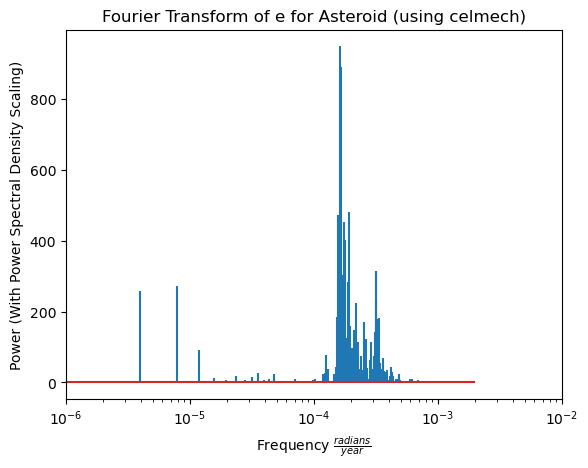

In [40]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e3))
e_ast = np.zeros(len(times))
ast_pomega = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2,indexIn=1, indexOut=2, max_order=2) #3:1 MMR

e_i = pham.calculate_energy()
print('Initial Energy: " '+ str(e_i))

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    e_ast[i] = pham.state.particles[1].e

e_f = pham.calculate_energy()
print('Final Energy: " '+ str(e_f))

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')
f,pxx = ft(times, e_ast)

plt.xlim(1e-6,1e-2)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.title('Fourier Transform of e for Asteroid (using celmech)')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-9.563257764425922e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:19<00:00, 5219.75it/s]


-9.563257764423725e-05
Energy Percent Change: 2.2971927622517973e-11 %
*** Simulation Complete ***
Time elapsed  = 16.236414086000877 seconds


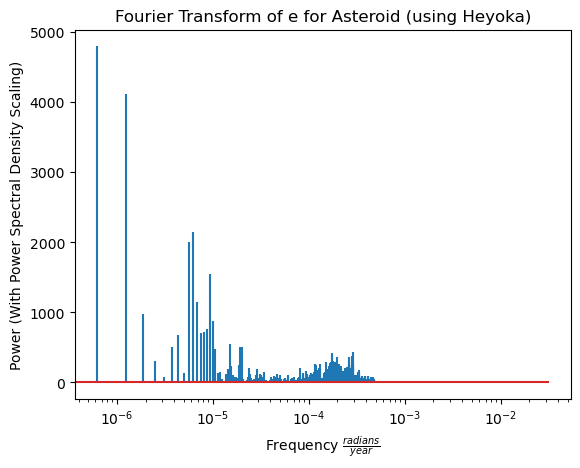

In [5]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2,indexIn=1, indexOut=2, max_order=2) #3:1 MMR

times, e_ast = hk_integrate(pham,1e7,1e5)
                           
f,pxx = ft(times, e_ast)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.title('Fourier Transform of e for Asteroid (using Heyoka)')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.show()